In [141]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3

conn = sqlite3.connect("fraud.db")

df = pd.read_csv("fraudTest.csv")
df.to_sql("fraudTest", conn, index = False, if_exists = "replace")

df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [142]:
# Queries SQL
query1 = """
SELECT COUNT (DISTINCT trans_num) AS "Numero total de transacciones"
FROM fraudTest """

query2 = """
SELECT COUNT (DISTINCT trans_num) AS "Numero de transacciones fraudulentas"
FROM fraudTest
WHERE is_fraud = 1 """

query3 = """ SELECT MAX(amt) AS Maximo, MIN(amt) AS Minimo
FROM fraudTest
WHERE is_fraud = 1 """

# Numero total de transacciones
df1 = pd.read_sql_query(query1, conn)
print(f"Numero total de transacciones: {df1.iloc[0]['Numero total de transacciones']}")

# Numero total de transacciones fraudulentas
df2 = pd.read_sql_query(query2, conn)
print(f"Numero total de transacciones fraudulentas: {df2.iloc[0]['Numero de transacciones fraudulentas']}")

# Maximo y minimo de transacciones fraudulentas
df3 = pd.read_sql(query3, conn)
print(f"Transacciones fraudulentas -->  Monto máximo: {df3.iloc[0]['Maximo']} - Monto mínimo: {df3.iloc[0]["Minimo"]}")

# Número de transacciones fraudulentas 
fraudes = df2.iloc[0]['Numero de transacciones fraudulentas']

# Número de transacciones NO fraudulentas
NO_fraudes =  df1.iloc[0]['Numero total de transacciones'] - fraudes

# Porcentaje de transacciones fraudulentas / total
print("Porcentaje de transacciones fraudulentas: " 
      f"{(df2.iloc[0]['Numero de transacciones fraudulentas'] / df1.iloc[0]['Numero total de transacciones']) * 100:.3f} %" )

Numero total de transacciones: 555719
Numero total de transacciones fraudulentas: 2145
Transacciones fraudulentas -->  Monto máximo: 1320.92 - Monto mínimo: 1.78
Porcentaje de transacciones fraudulentas: 0.386 %


---

## **Monto promedio fraude vs no fraude**

---

In [143]:
# Querie SQL

query = """ SELECT is_fraud AS "Es fraude", AVG(amt) AS "Monto promedio" FROM fraudTest
GROUP BY is_fraud """

df1 = pd.read_sql_query(query, conn)    # 0 = NO fraude
                                        # 1 = fraude
print(df1)

   Es fraude  Monto promedio
0          0       67.614408
1          1      528.356494


---

> Se puede observar una gran diferencia entre el monto promedio de una transacción fraudulenta vs una transacción NO fraudulenta.
<br> 
<br> A continuación veremos un gráfico con la distribución de las transacciones para entender mejor estos números y descubrir si realmente podemos obtener conclusiones al respecto o se trata de casos excepcionales que modifican mucho los promedios.

---

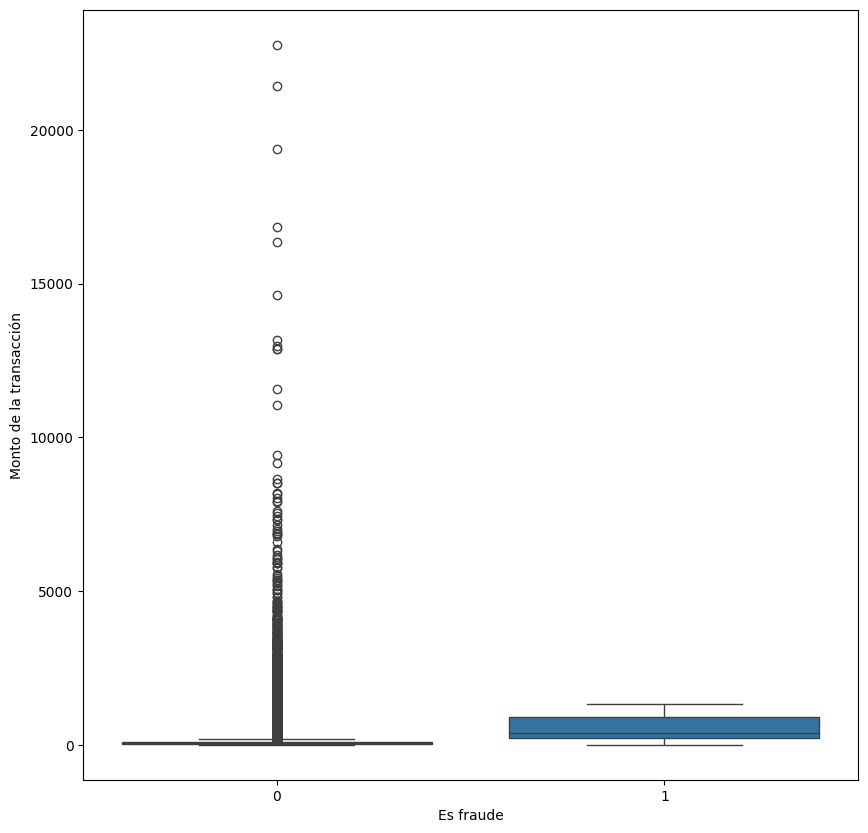

In [144]:
# Query SQL

# NO fraudulentas
query0 = """ SELECT is_fraud AS "Es fraude", amt AS "Monto de la transacción" FROM fraudTest 
WHERE is_fraud = 0 """

# Fraudulentas
query1 = """ SELECT is_fraud AS "Es fraude", amt AS "Monto de la transacción" FROM fraudTest 
WHERE is_fraud = 1 """

df0 = pd.read_sql_query(query0, conn)
df1 = pd.read_sql_query(query1, conn)

df0["Grupo"] = "No es fraude"
df1["Grupo"] = "Es fraude"

df2 = pd.concat([df0, df1])

plt.figure(figsize = (10,10))
sns.boxplot(x = "Es fraude", y = "Monto de la transacción", data = df2)
plt.show()


---
<br>

> Si bien se observan diferencias en los montos promedio entre transacciones fraudulentas y no fraudulentas, la alta dispersión y presencia de valores extremos dificultan extraer conclusiones sólidas utilizando esta variable de manera aislada.
<br>
<br>
No obstante, el análisis se conserva por su potencial valor predictivo dentro del modelo posterior.

---

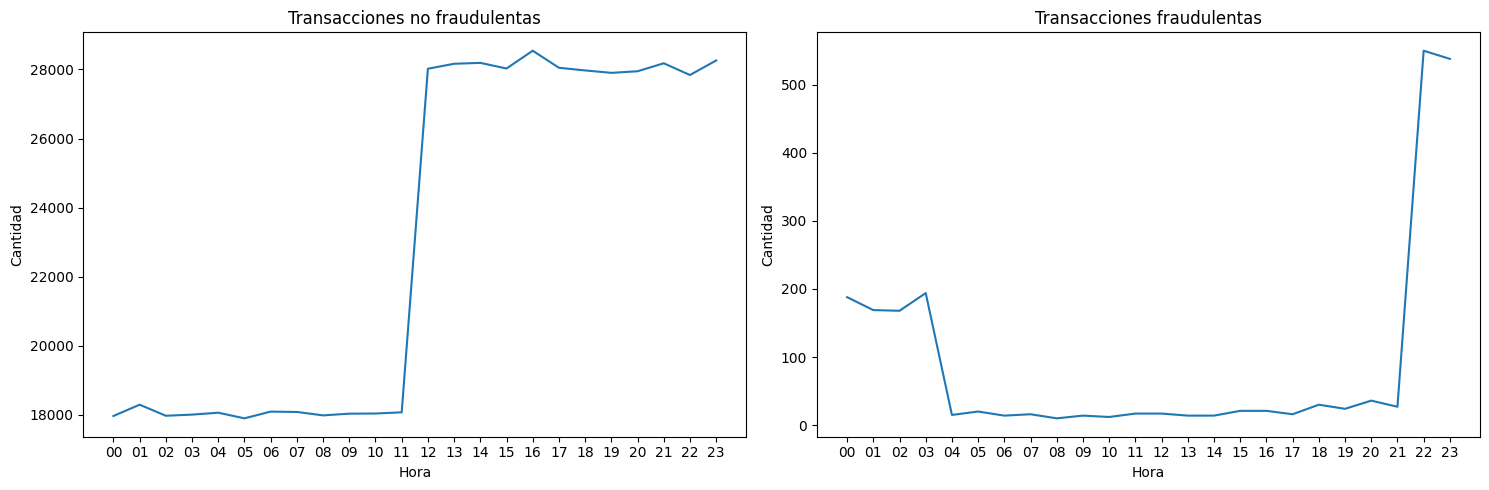

 El 86.200% de las transacciones fraudulentas se da entre las 21 y 04hs
 El 31.535% de las transacciones NO fraudulentas se da entre las 21 y 04hs


In [145]:
# Queries SQL
query1 = """
WITH Horario AS (SELECT trans_num, strftime('%H', trans_date_trans_time) AS Hora
FROM fraudTest
WHERE is_fraud = 0)
SELECT Hora, COUNT(trans_num) AS "Numero de transacciones"
FROM Horario
GROUP BY Hora """

query2 = """ 
WITH Horario AS (SELECT trans_num, strftime('%H', trans_date_trans_time) AS Hora
FROM fraudTest
WHERE is_fraud = 1)
SELECT Hora, COUNT(trans_num) AS "Numero de transacciones fraudulentas"
FROM Horario
GROUP BY Hora """

query3 = """ WITH Horario AS (SELECT trans_num, strftime('%H', trans_date_trans_time) AS Hora
FROM fraudTest
WHERE is_fraud = 1)
SELECT COUNT(trans_num) AS "Fraudes restringidos"
FROM Horario
WHERE Hora >= '21' OR Hora <= '04'  """

query4 = """ WITH Horario AS (SELECT trans_num, strftime('%H', trans_date_trans_time) AS Hora
FROM fraudTest
WHERE is_fraud = 0)
SELECT COUNT(trans_num) AS "NO fraudes restringidos"
FROM Horario
WHERE Hora >= '21' OR Hora <= '04'  """

fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Gráfico transacciones no fraudulentas
df1 = pd.read_sql_query(query1, conn)
axes[0].plot(df1["Hora"], df1["Numero de transacciones"])
axes[0].set_title("Transacciones no fraudulentas")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Cantidad")

# Gráfico transacciones fraudulentas
df2 = pd.read_sql_query(query2, conn)
axes[1].plot(df2["Hora"], df2["Numero de transacciones fraudulentas"])
axes[1].set_title("Transacciones fraudulentas")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

# Porcentaje de fraudes entre 21 y 04hs sobre el total de fraudes
df3 = pd.read_sql(query3, conn)
print(f" El {df3.iloc[0]['Fraudes restringidos'] / fraudes * 100:.3f}% de las transacciones fraudulentas se da entre las 21 y 04hs")

# Porcentaje de NO fraudes entre 21 y 04hs sobre el total de NO fraudes
df4 = pd.read_sql(query4, conn)
print(f" El {df4.iloc[0]['NO fraudes restringidos'] / NO_fraudes * 100:.3f}% de las transacciones NO fraudulentas se da entre las 21 y 04hs")

---

## **Análisis de transacciones por horario**

### **Transacciones no fraudulentas**
En el primer gráfico se observa un incremento significativo en el número de transacciones **no fraudulentas** a partir de las 11:00 hs, manteniéndose elevado hasta las 23:00 hs.  
Este comportamiento es consistente con los horarios habituales de actividad bancaria y comercial, donde se concentra la mayor parte de las operaciones.

### **Transacciones fraudulentas**
En el segundo gráfico se aprecia un patrón diferente. La cantidad de transacciones fraudulentas es relativamente baja durante el horario diurno, pero aumenta en horarios menos habituales, especialmente entre las 21:00 y las 04:00 hs.

--- 

### **Conclusión**
Se identifica un comportamiento diferencial entre transacciones fraudulentas y las no fraudulentas:
- Las transacciones normales se concentran en horarios laborales.
- Las fraudulentas tienden a ocurrir en horarios nocturnos o de baja actividad.

Este patrón sugiere que el horario puede ser una variable relevante para la detección de fraude.

---

In [146]:
query1 = """ SELECT COUNT(trans_num) AS "Número de transacciones totales" 
FROM fraudTest """

query2 = """ SELECT COUNT(trans_num) AS "Número de transacciones fraudulentas"
FROM fraudTest 
WHERE is_fraud = 1 """

df1 = pd.read_sql(query1, conn)
df2 = pd.read_sql(query2, conn)



---
---
<br>

#### Veamos si ese rango de horario no habitual se relaciona con el horario en sí, o es una cuestión de geolocalización de los fraudes más frecuentes.

---

In [147]:
fraud_df = df[df["is_fraud"] == 1]

import folium
from folium.plugins import HeatMap

# centro del mapa (promedio de coordenadas)
mapa = folium.Map(location = [df["lat"].mean(), df["long"].mean()], zoom_start = 5)

# datos para heatmap
heat_data = list(zip(fraud_df["lat"], fraud_df["long"]))

HeatMap(heat_data).add_to(mapa)

mapa
from IPython.display import display
display(mapa)
#mapa._repr_html_()


---

## **Análisis geográfico del fraude**

A partir del mapa de calor generado utilizando las coordenadas (`lat`, `long`) de las transacciones fraudulentas, se observa una alta concentración en una región específica, principalmente en Estados Unidos. No se evidencia una distribución global significativa que sugiera actividad relevante en otras zonas del mundo.

### Interpretación

Este resultado permite descartar, con un buen nivel de confianza, la hipótesis de que el patrón horario observado en el fraude esté explicado por diferencias de zona horaria a nivel global. Es decir:

- No hay evidencia de que el fraude esté concentrado en regiones con husos horarios opuestos.
- La actividad fraudulenta no parece responder a comportamientos diurnos en otras partes del mundo.

---

### **Conclusión**

- El **horario** es una variable relevante en la detección de fraude.
- Las transacciones fraudulentas tienden a ocurrir en momentos donde hay menor supervisión o menor volumen de actividad normal.

<br>

---


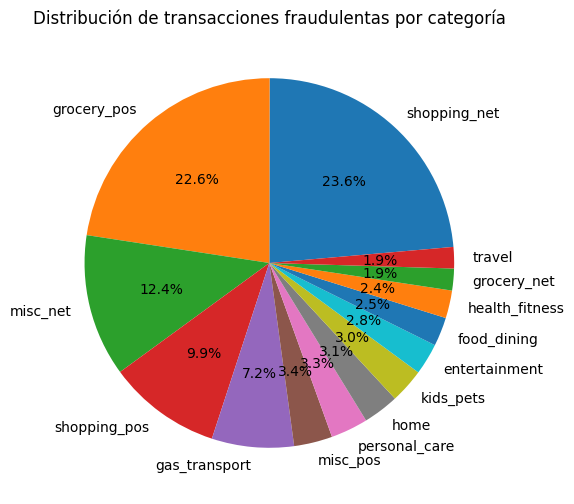

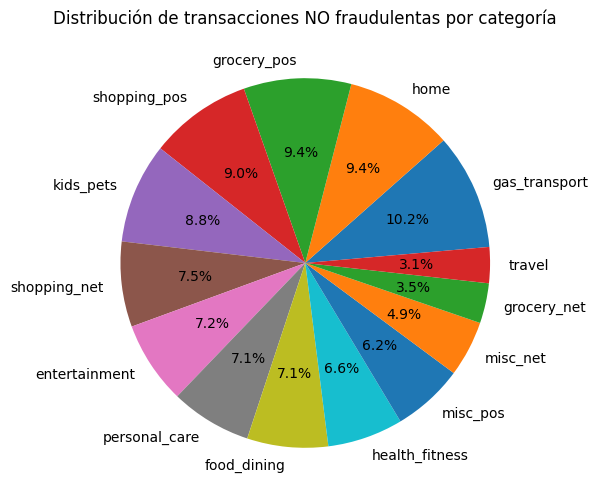

In [148]:
query1 = """
SELECT category AS Categoria, COUNT (DISTINCT trans_num) AS "Numero de transacciones fraudulentas"
FROM fraudTest
WHERE is_fraud = 1
GROUP BY Categoria
ORDER BY "Numero de transacciones fraudulentas" DESC """

query2 = """
SELECT category AS Categoria, COUNT (DISTINCT trans_num) AS "Numero de transacciones NO fraudulentas"
FROM fraudTest
WHERE is_fraud = 0
GROUP BY Categoria
ORDER BY "Numero de transacciones NO fraudulentas" DESC """

# Grafico1
df1 = pd.read_sql(query1, conn)
plt.figure(figsize = (6, 6))
plt.pie(
    df1["Numero de transacciones fraudulentas"],
    labels = df1["Categoria"],
    autopct = '%1.1f%%',   # muestra porcentajes
    startangle = 5)
plt.title("Distribución de transacciones fraudulentas por categoría")
plt.show()

# Grafico2
df2 = pd.read_sql(query2, conn)
plt.figure(figsize = (6, 6))
plt.pie(
    df2["Numero de transacciones NO fraudulentas"],
    labels = df2["Categoria"],
    autopct = '%1.1f%%',   # muestra porcentajes
    startangle = 5)
plt.title("Distribución de transacciones NO fraudulentas por categoría")
plt.show()

---

### **Conclusión**

El análisis de estos gráficos muestra que las transacciones **fraudulentas** se concentran fuertemente en unas pocas categorías. En particular, **shopping_net, grocery_pos y misc_net**, lo que evidencia un patrón claro de concentración.

En contraste, las transacciones **NO fraudulentas** muestran una distribución más equilibrada entre categorías, lo que refuerza la idea de que el fraude tiende a concentrarse en canales y contextos específicos en lugar de replicar el comportamiento normal de consumo.

---

---

## **Modelo de entrenamiento para detección del fraude**

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Agrego columnas
df["hour"] = pd.to_datetime(df["trans_date_trans_time"]).dt.hour
df["is_night"] = df["hour"].apply(lambda x: 1 if x >= 21 or x <= 4 else 0)

# Selección de variables más relevantes
features = ["amt", "lat", "long", "city_pop", "unix_time", "merch_lat", "merch_long", "hour", "is_night"]

X = df[features]
y = df["is_fraud"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y)

# Modelo
model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
model.fit(X_train, y_train)

# Probabilidades
y_probs = model.predict_proba(X_test)[:, 1] 

In [ ]:
from sklearn.metrics import precision_score, recall_score

umbral = 0.8
y_pred = (y_probs >= umbral).astype(int)

precision = precision_score(y_test, y_pred)
deteccion = recall_score(y_test, y_pred)

# Ratio de falso positivo
tn1, fp1, fn1, tp1 = confusion_matrix(y_test, y_pred).ravel()
rfp1 = fp1 / (fp1 + tn1)

print(f"Precision: {precision * 100:.3f}%")     # % de los fraudes detectados
print(f"Detección: {deteccion * 100:.3f}%")     # % de fraudes que realmente son fraude
print(f"RFP: {rfp1 * 100:.3f}%")                # % detectado pero no son fraude

Precision: 11.984%
Detección: 51.863%
RFP: 1.477%


In [ ]:
umbral = 0.7
y_pred = (y_probs >= umbral).astype(int)

precision = precision_score(y_test, y_pred)
deteccion = recall_score(y_test, y_pred)

# Ratio de falso positivo
tn2, fp2, fn2, tp2 = confusion_matrix(y_test, y_pred).ravel()
rfp2 = fp2 / (fp2 + tn2)

print(f"Precision: {precision * 100:.3f}%")     # % de los fraudes detectados
print(f"Detección: {deteccion * 100:.3f}%")     # % de fraudes que realmente son fraude
print(f"RFP: {rfp2 * 100:.3f}%")                # % detectado pero no son fraude

Precision: 11.997%
Detección: 67.081%
RFP: 1.908%


In [ ]:
# Supuestos
monto_prom = 67.614     # Monto promedio de fraudes
fraudes_detec1 = tp1    # Umbral 0.8
fraudes_detec2 = tp2    # Umbral 0.7

dinero_ahorrado1 = monto_prom * fraudes_detec1
dinero_ahorrado2 = monto_prom * fraudes_detec2

print(f"Umbral 0.8 --> Dinero potencialmente ahorrado: ${dinero_ahorrado1:.3f}")
print(f"Umbral 0.7 --> Dinero potencialmente ahorrado: ${dinero_ahorrado2:.3f}")

Umbral 0.8 --> Dinero potencialmente ahorrado: $22583.076
Umbral 0.7 --> Dinero potencialmente ahorrado: $29209.248


---

### Resultados obtenidos

| Umbral | Precision | Detección | RFP |
|----------|----------|--------|------|
| 0.8      | 11.98%   | 51.86% | 1.48% |
| 0.7      | 11.99%   | 67.08% | 1.91% |

<br>

---

### Interpretación

- Al reducir el umbral de 0.8 a 0.7:
  - Se incrementa significativamente la **detección de fraude** de 52% a 67%.
  - Aumenta levemente la **tasa de falsos positivos (RFP)** de 1.48% a 1.91%.
  - La **precisión se mantiene estable (~12%)**.

> Incrementa el dinero potencialmente recuperado en **~29%** --> ($22,583 → $29,209)

---

### Decisión de negocio

- **Umbral alto (0.8)**  
  - Menor impacto en clientes legítimos.  
  - Mayor cantidad de fraude no detectado.  
  - Menor dinero recuperado

- **Umbral más bajo (0.7)**  
  - Mayor detección de fraude.  
  - Ligero aumento en fricción al cliente.  
  - Mayor ahorro económico

---

> El modelo permite reducir de forma significativa las pérdidas económicas asociadas a fraude, manteniendo una experiencia de usuario controlada.

---

### Conclusión

El modelo demuestra ser una herramienta efectiva para la detección de fraude.  
La elección del umbral de decisión permite ajustar el equilibrio entre **seguridad (detección del fraude) y experiencia del cliente (falsos positivos)**


---

---

### **Conclusiones generales:** Para una detección de fraudes más acotada podriamos enfocarnos en los siguientes items

- Centrarse en las transacciones que se efectúan entre 21:00 - 04:00hs.
- Enfocarse en la seguridad en las compras en línea y tiendas de comestibles. 

> Con un modelo de detección de fraude como el analizado, podremos ahorrar el **~20%** del dinero perdido en fraudes vs un impacto moderado/leve con clientes legítimos.

#### Números reales: 
-  El **86.200%** de las transacciones **fraudulentas** se da entre las **21:00 y 04:00hs**.
- El **58,60%** de los **fraudes** se encuentran en las tiendas: **shopping_net, grocery_pos y misc_net**.
- Dinero ahorado: **~$29.209**.

---

---